Min Value of TimeRadians: 0.000199
Max Value of TimeRadians: 6.28318


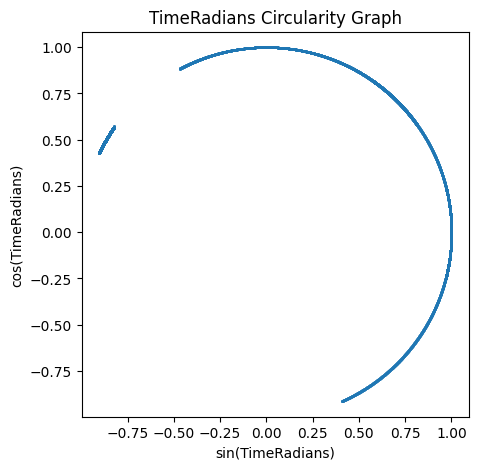

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset first!
raw = pd.read_csv('consolidated_dataset_raw.csv')

# Step A: Numerical check bounds (should tightly map between 0 and 6.28)
print("Min Value of TimeRadians:", raw['TimeRadians'].min())
print("Max Value of TimeRadians:", raw['TimeRadians'].max())

# Step B: Scatter plot to confirm perfect circular structure
plt.figure(figsize=(5, 5))
plt.scatter(np.sin(raw['TimeRadians']), np.cos(raw['TimeRadians']), s=1, alpha=0.3)
plt.title("TimeRadians Circularity Graph")
plt.xlabel("sin(TimeRadians)")
plt.ylabel("cos(TimeRadians)")
plt.axis('equal')
plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset first!
raw = pd.read_csv('consolidated_dataset_raw.csv')

# Step A: Numerical check bounds (should tightly map between 0 and 6.28)
print("Min Value of TimeRadians:", raw['TimeRadians'].min())
print("Max Value of TimeRadians:", raw['TimeRadians'].max())

# Step B: Scatter plot to confirm perfect circular structure

Min Value of TimeRadians: 0.000199
Max Value of TimeRadians: 6.28318


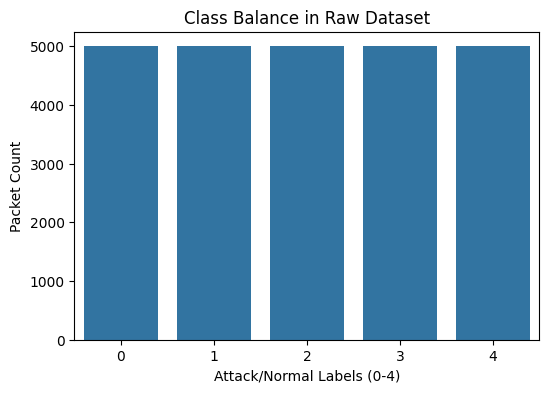

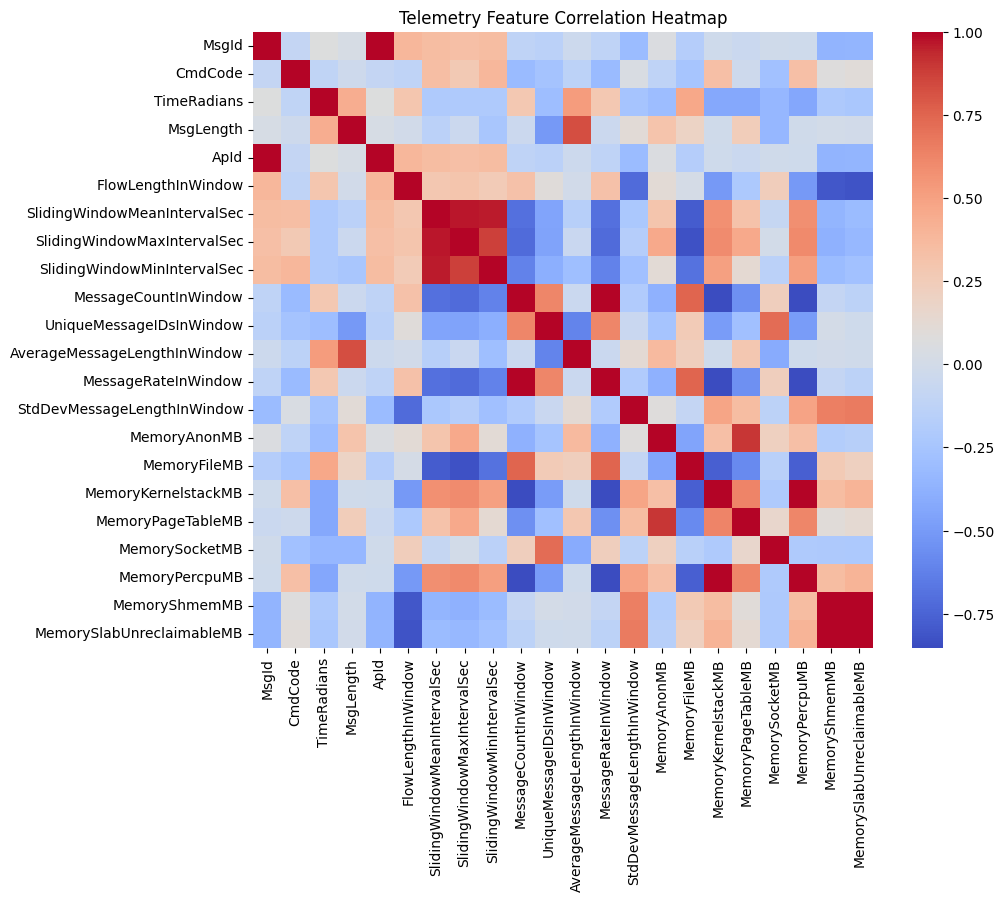

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Class Balance Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=raw)
plt.title("Class Balance in Raw Dataset")
plt.xlabel("Attack/Normal Labels (0-4)")
plt.ylabel("Packet Count")
plt.show()

# 2. Correlation Matrix Heatmap
# Find numeric columns present in both datasets (excluding Label)
noised = pd.read_csv("noised_dataset.csv")
common_cols = [c for c in noised.columns if c in raw.columns and c != "Label"]

plt.figure(figsize=(10, 8))
corr_matrix = raw[common_cols].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Telemetry Feature Correlation Heatmap")
plt.show()

In [4]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
import xgboost as xgb

# 1. Load the data files from your folder
raw = pd.read_csv("consolidated_dataset_raw.csv")
noised = pd.read_csv("noised_dataset.csv")

# 2. Extract columns (dropping the 'Label' column for training)
# # 2. Extract columns (Find columns present in BOTH datasets, excluding Label)
common_cols = [c for c in noised.columns if c in raw.columns and c != "Label"]
Xtr, ytr = raw[common_cols], raw["Label"]
Xte, yte = noised[common_cols], noised["Label"].astype(int)

print(f"Raw dataset shape: {raw.shape}")
print(f"Noised dataset shape: {noised.shape}")

# 3. Train the baseline model to check numbers
model = xgb.XGBClassifier(n_estimators=150, max_depth=6, eval_metric="mlogloss", n_jobs=4)
model.fit(Xtr, ytr)
pred = model.predict(Xte)

# 4. Print results to verify against the plan's baseline
print("\n--- Baseline Metrics Audit ---")
print("Accuracy:", accuracy_score(yte, pred))
print("Macro F1:", f1_score(yte, pred, average="macro"))

Raw dataset shape: (25000, 31)
Noised dataset shape: (22465, 23)

--- Baseline Metrics Audit ---
Accuracy: 0.6890718896060538
Macro F1: 0.6967130871997729


In [5]:
import sys
!{sys.executable} -m pip install shap
%pip install pandas numpy scikit-learn xgboost seaborn matplotlib



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\haasi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


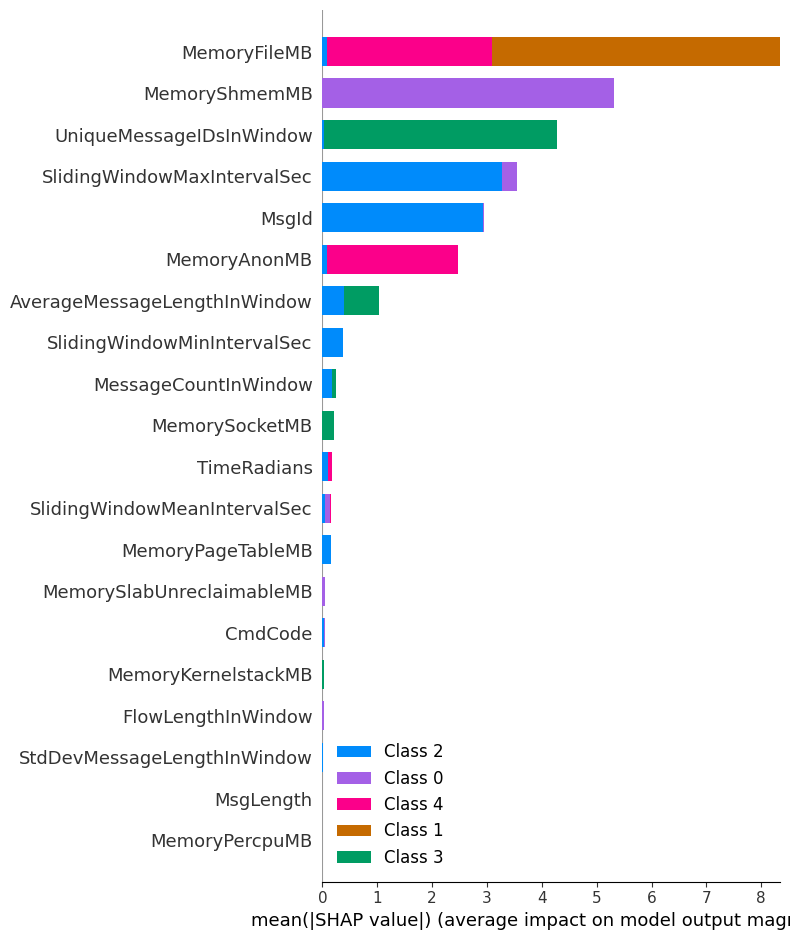

In [6]:
import shap

# Initialize SHAP TreeExplainer on your trained XGBoost model
explainer = shap.TreeExplainer(model)
shap_values = explainer(Xte)

# Summary plot showing feature impact across all classes
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, Xte, feature_names=common_cols)

In [7]:
import numpy as np

# Apply sine and cosine transformations
raw['Time_Sin'] = np.sin(raw['TimeRadians'])
raw['Time_Cos'] = np.cos(raw['TimeRadians'])

noised['Time_Sin'] = np.sin(noised['TimeRadians'])
noised['Time_Cos'] = np.cos(noised['TimeRadians'])

# Update feature list to drop linear TimeRadians and include new cyclical features
feature_cols = [c for c in common_cols if c != 'TimeRadians'] + ['Time_Sin', 'Time_Cos']

print(f"Updated feature count: {len(feature_cols)}")

Updated feature count: 23


In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Scale features for Autoencoder
scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(raw[feature_cols])
Xte_scaled = scaler.transform(noised[feature_cols])

print(f"Scaled Train Shape (Autoencoder ready): {Xtr_scaled.shape}")

# 2. Reshape into 3D Sequence Tensors for LSTM (samples, time_steps, features)
TIME_STEPS = 10  # Lookback window length

def create_sequences(data, seq_length=10):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i : i + seq_length])
    return np.array(sequences)

Xtr_lstm = create_sequences(Xtr_scaled, seq_length=TIME_STEPS)
Xte_lstm = create_sequences(Xte_scaled, seq_length=TIME_STEPS)

print(f"LSTM Train Tensor Shape: {Xtr_lstm.shape}")  # (N, 10, num_features)
print(f"LSTM Test Tensor Shape:  {Xte_lstm.shape}")

Scaled Train Shape (Autoencoder ready): (25000, 23)
LSTM Train Tensor Shape: (24991, 10, 23)
LSTM Test Tensor Shape:  (22456, 10, 23)


In [9]:
!pip install pandas numpy scikit-learn xgboost seaborn matplotlib

'pip' is not recognized as an internal or external command,
operable program or batch file.
